## Assignment 4 - Market Basket dataset Association Rule Mining

### Sruthilaya Umasankari Soma Shanmuga Sundaram, Date of Submission 05/07/2026

## Q1 - Robust Data Preprocessing

### a) Create clean_transactions(filepath)

In [23]:
import csv


def clean_transactions(filepath):
    with open(filepath, newline="") as f:
        rows = list(csv.reader(f))
    #dynamic detction of no.of rows and cols
    n_rows = len(rows)
    n_cols = max((len(r) for r in rows), default=0)

    transactions = []
    nan_count = 0
    item_counts = []
    unique_items = set()

    for row in rows:
        items = []
        seen = set()
        for cell in row:
            value = cell.strip()
            if value == "": #skipping nan values and keeping the count of records
                nan_count += 1
                continue
            if value not in seen: #only adding unique values
                seen.add(value)
                items.append(value)
        nan_count += n_cols - len(row)
        transactions.append(items)
        item_counts.append(len(items))
        unique_items.update(items)

    avg_items = (sum(item_counts) / n_rows) if n_rows else 0.0
    print("Summary report")
    print(f"  Total transactions: {n_rows}")
    print(f"  Detected columns: {n_cols}")
    print(f"  Average items per transaction: {avg_items:.2f}")
    print(f"  Total unique items across dataset: {len(unique_items)}")
    print(f"  NaN/empty cells removed: {nan_count}")

    return transactions

### b) Run the function on the dataset and print the summary

In [24]:
transactions = clean_transactions("dataset/Market_Basket_Optimisation.csv")
transactions[:3]

Summary report
  Total transactions: 7501
  Detected columns: 20
  Average items per transaction: 3.91
  Total unique items across dataset: 119
  NaN/empty cells removed: 120657


[['shrimp',
  'almonds',
  'avocado',
  'vegetables mix',
  'green grapes',
  'whole weat flour',
  'yams',
  'cottage cheese',
  'energy drink',
  'tomato juice',
  'low fat yogurt',
  'green tea',
  'honey',
  'salad',
  'mineral water',
  'salmon',
  'antioxydant juice',
  'frozen smoothie',
  'spinach',
  'olive oil'],
 ['burgers', 'meatballs', 'eggs'],
 ['chutney']]

### c) Unit tests for edge cases

In [25]:
import unittest
import tempfile
import os


class TestCleanTransactions(unittest.TestCase):
    def _write_csv(self, content):
        f = tempfile.NamedTemporaryFile(mode="w", suffix=".csv", delete=False, newline="")
        f.write(content)
        f.close()
        return f.name

    def test_entirely_nan_row(self):
        path = self._write_csv("apple,bread\n,,\n")
        try:
            result = clean_transactions(path)
            self.assertEqual(result[1], [])
        finally:
            os.remove(path)

    def test_duplicate_items_removed(self):
        path = self._write_csv("apple,apple,bread\n")
        try:
            result = clean_transactions(path)
            self.assertEqual(result[0], ["apple", "bread"])
        finally:
            os.remove(path)

    def test_empty_csv_file(self):
        path = self._write_csv("")
        try:
            result = clean_transactions(path)
            self.assertEqual(result, [])
        finally:
            os.remove(path)


unittest.main(argv=["first-arg-is-ignored"], exit=False)

...
----------------------------------------------------------------------
Ran 3 tests in 0.012s

OK


Summary report
  Total transactions: 1
  Detected columns: 3
  Average items per transaction: 2.00
  Total unique items across dataset: 2
  NaN/empty cells removed: 0
Summary report
  Total transactions: 0
  Detected columns: 0
  Average items per transaction: 0.00
  Total unique items across dataset: 0
  NaN/empty cells removed: 0
Summary report
  Total transactions: 2
  Detected columns: 3
  Average items per transaction: 1.00
  Total unique items across dataset: 2
  NaN/empty cells removed: 4


In [ ]:
#pip install apyori

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=6014 sha256=4f8e322f61a6456d0dac5103d7c6b724b9cf259bb180c60beec38a81265354f8
  Stored in directory: c:\users\uma\appdata\local\pip\cache\wheels\c0\f2\a2\a0a22921ec5339be2d78a38b6da01b2e7e9754d3570c3311d7
Successfully built apyori
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Q2 -  Parameter Sensitivity Experiment

### a) run_apriori_experiment()

In [26]:
import pandas as pd
from apyori import apriori


def run_apriori_experiment(transactions, support_values, confidence_values, min_lift, min_length, max_length):
    records = []
    for min_support in support_values:
        for min_confidence in confidence_values:
            rules = apriori(
                transactions=transactions,
                min_support=min_support,
                min_confidence=min_confidence,
                min_lift=min_lift,
                min_length=min_length,
                max_length=max_length,
            )
            results = list(rules)
            num_rules = len(results)
            if num_rules:
                lifts = [result[2][0][3] for result in results]
                avg_lift = sum(lifts) / num_rules
                max_lift = max(lifts)
            else:
                avg_lift = 0.0
                max_lift = 0.0
            records.append({
                "min_support": min_support,
                "min_confidence": min_confidence,
                "num_rules": num_rules,
                "avg_lift": avg_lift,
                "max_lift": max_lift,
            })
    return pd.DataFrame(records)


support_values = [0.001, 0.002, 0.003, 0.005, 0.01]
confidence_values = [0.1, 0.2, 0.3, 0.5]

experiment_df = run_apriori_experiment(
    transactions,
    support_values=support_values,
    confidence_values=confidence_values,
    min_lift=3,
    min_length=2,
    max_length=2,
)
experiment_df


,min_support,min_confidence,num_rules,avg_lift,max_lift
0,0.001,0.1,77,4.494971,12.822222
1,0.001,0.2,29,4.671100,12.453237
2,0.001,0.3,8,3.851391,4.700812
3,0.001,0.5,0,0.000000,0.000000
4,0.002,0.1,26,4.174059,8.890601
5,0.002,0.2,13,3.971431,5.164271
6,0.002,0.3,6,3.894666,4.700812
7,0.002,0.5,0,0.000000,0.000000
8,0.003,0.1,12,3.970506,5.164271
9,0.003,0.2,9,4.152923,5.164271


### b) Visualisations from the experiment

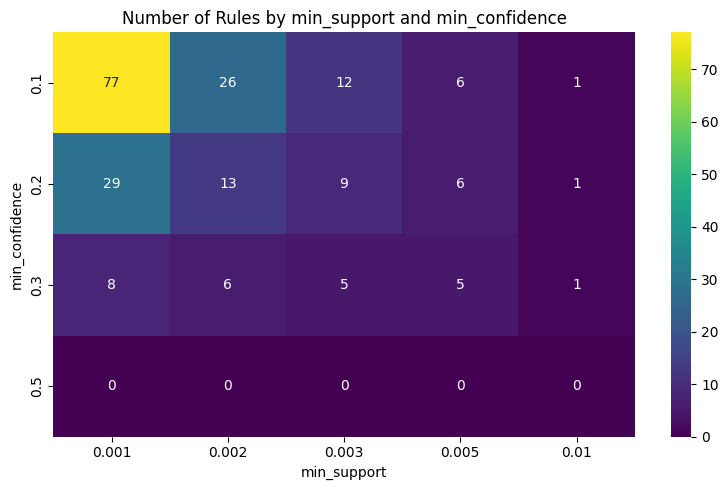

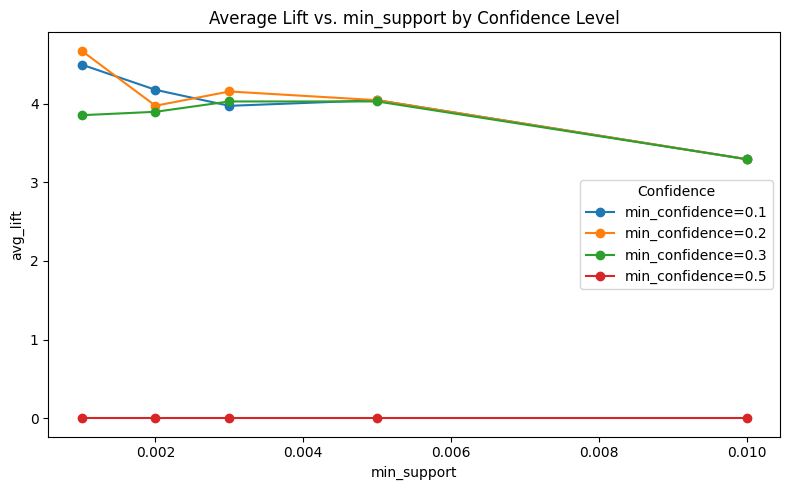

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# (i) Heatmap: min_support vs min_confidence, color = num_rules
heatmap_data = experiment_df.pivot(index="min_confidence", columns="min_support", values="num_rules")

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="viridis")
plt.xlabel("min_support")
plt.ylabel("min_confidence")
plt.title("Number of Rules by min_support and min_confidence")
plt.tight_layout()
plt.show()

# (ii) Line plot: avg_lift vs min_support, one line per confidence level
plt.figure(figsize=(8, 5))
for confidence in confidence_values:
    subset = experiment_df[experiment_df["min_confidence"] == confidence]
    plt.plot(subset["min_support"], subset["avg_lift"], marker="o", label=f"min_confidence={confidence}")

plt.xlabel("min_support")
plt.ylabel("avg_lift")
plt.title("Average Lift vs. min_support by Confidence Level")
plt.legend(title="Confidence")
plt.tight_layout()
plt.show()


### c) Write up based on the above visualisations

In [28]:
"""
At the min_support of 0.001 and min_confidence of 0.1 we get 77 rules with 
avg lift 4.49), the largest set but with many weak associations near the 
lift=3 cutoff. When raising the confidence to 0.2 reduces this to 29 rules 
while *increasing* avg lift to 4.67. The dropped rules were dragging quality down, 
not adding value. Beyond min_support=0.003 the rule count drops to 5-12, and
confidence of 0.5 yields 0 rules at every support level  which is too strict for
this sparse data. So the recommended min_support=0.001, min_confidence=0.2
has the highest avg lift (4.67) of any non-empty setting while still
keeping a healthy 29 rules to analyze.
"""

'\nAt the min_support of 0.001 and min_confidence of 0.1 we get 77 rules with \navg lift 4.49), the largest set but with many weak associations near the \nlift=3 cutoff. When raising the confidence to 0.2 reduces this to 29 rules \nwhile *increasing* avg lift to 4.67. The dropped rules were dragging quality down, \nnot adding value. Beyond min_support=0.003 the rule count drops to 5-12, and\nconfidence of 0.5 yields 0 rules at every support level  which is too strict for\nthis sparse data. So the recommended min_support=0.001, min_confidence=0.2\nhas the highest avg lift (4.67) of any non-empty setting while still\nkeeping a healthy 29 rules to analyze.\n'

## Q3: Generalized inspect() and Rule Analysis Pipeline

### a) parse_rules(results)

In [29]:
import pandas as pd


def parse_rules(results):
    records = []
    for result in results:
        support = result[1]
        for ordered_stat in result[2]:
            lhs = ordered_stat[0]
            rhs = ordered_stat[1]
            confidence = ordered_stat[2]
            lift = ordered_stat[3]
            if not lhs or not rhs: #we skip any rule where on side is empty
                continue
            records.append({
                "LHS": ", ".join(sorted(lhs)),
                "RHS": ", ".join(sorted(rhs)),
                "num_items_lhs": len(lhs),
                "num_items_rhs": len(rhs),
                "Support": support,
                "Confidence": confidence,
                "Lift": lift,
            })
    return pd.DataFrame(records)


from apyori import apriori

rules_q3 = apriori(
    transactions=transactions,
    min_support=0.003,
    min_confidence=0.2,
    min_lift=3,
    min_length=2,
    max_length=3,
)
parsed_rules = parse_rules(list(rules_q3))
parsed_rules

,LHS,RHS,num_items_lhs,num_items_rhs,Support,Confidence,Lift
0,light cream,chicken,1,1,0.004533,0.290598,4.843951
1,mushroom cream sauce,escalope,1,1,0.005733,0.300699,3.790833
2,pasta,escalope,1,1,0.005866,0.372881,4.700812
3,fromage blanc,honey,1,1,0.003333,0.245098,5.164271
4,herb & pepper,ground beef,1,1,0.015998,0.323450,3.291994
...,...,...,...,...,...,...,...
69,"mineral water, whole wheat pasta",olive oil,2,1,0.003866,0.402778,6.115863
70,"pancakes, spaghetti",olive oil,2,1,0.005066,0.201058,3.052910
71,"olive oil, tomatoes",spaghetti,2,1,0.004399,0.611111,3.509912
72,"spaghetti, tomatoes",olive oil,2,1,0.004399,0.210191,3.191586


### b) filter_rules()

In [30]:
def filter_rules(df, min_support=None, min_confidence=None, min_lift=None, contains_item=None):
    filtered = df

    if min_support is not None:
        filtered = filtered[filtered["Support"] >= min_support]
    if min_confidence is not None:
        filtered = filtered[filtered["Confidence"] >= min_confidence]
    if min_lift is not None:
        filtered = filtered[filtered["Lift"] >= min_lift]
    if contains_item is not None:
        in_lhs = filtered["LHS"].str.split(", ").apply(lambda items: contains_item in items)
        in_rhs = filtered["RHS"].str.split(", ").apply(lambda items: contains_item in items)
        filtered = filtered[in_lhs | in_rhs]

    return filtered.reset_index(drop=True)


# Demonstrating for rules involving "mineral water" with a lift above 3
mineral_water_rules = filter_rules(parsed_rules, min_lift=3, contains_item="mineral water")
mineral_water_rules

,LHS,RHS,num_items_lhs,num_items_rhs,Support,Confidence,Lift
0,"mineral water, shrimp",frozen vegetables,2,1,0.007199,0.305085,3.200616
1,"herb & pepper, mineral water",ground beef,2,1,0.006666,0.390625,3.975683
2,light cream,"mineral water, spaghetti",1,2,0.003200,0.205128,3.434524
3,"mineral water, soup",olive oil,2,1,0.005199,0.225434,3.423030
4,"mineral water, whole wheat pasta",olive oil,2,1,0.003866,0.402778,6.115863


### c) compute_custom_score()

In [31]:
def _min_max_normalize(series):
    span = series.max() - series.min()
    if span == 0:
        return pd.Series(0.0, index=series.index)
    return (series - series.min()) / span


def compute_custom_score(df, w_support=1.0, w_confidence=1.0, w_lift=1.0):
    result = df.copy()
    normalized_support = _min_max_normalize(result["Support"])
    normalized_confidence = _min_max_normalize(result["Confidence"])
    normalized_lift = _min_max_normalize(result["Lift"])

    result["normalized_support"] = normalized_support
    result["normalized_confidence"] = normalized_confidence
    result["normalized_lift"] = normalized_lift
    result["weighted_score"] = (
        w_support * normalized_support
        + w_confidence * normalized_confidence
        + w_lift * normalized_lift
    )
    return result


scored_rules = compute_custom_score(parsed_rules, w_support=1.0, w_confidence=1.5, w_lift=2.0)

top10_by_score = scored_rules.nlargest(10, "weighted_score")
top10_by_lift = scored_rules.nlargest(10, "Lift")

print("Top 10 rules by weighted_score (weights 1.0, 1.5, 2.0):")
display(top10_by_score[["LHS", "RHS", "Support", "Confidence", "Lift", "weighted_score"]])

print("\nTop 10 rules by Lift alone:")
display(top10_by_lift[["LHS", "RHS", "Support", "Confidence", "Lift"]])


Top 10 rules by weighted_score (weights 1.0, 1.5, 2.0):


,LHS,RHS,Support,Confidence,Lift,weighted_score
69,"mineral water, whole wheat pasta",olive oil,0.003866,0.402778,6.115863,2.698312
58,"spaghetti, tomato sauce",ground beef,0.003066,0.489362,4.980600,2.179698
15,"cereals, ground beef",spaghetti,0.003066,0.676471,3.885303,2.065809
32,"french fries, herb & pepper",ground beef,0.003200,0.461538,4.697422,1.920145
16,"cereals, spaghetti",ground beef,0.003066,0.460000,4.681764,1.894914
2,pasta,escalope,0.005866,0.372881,4.700812,1.848783
24,"chocolate, herb & pepper",ground beef,0.003999,0.441176,4.490183,1.784506
71,"olive oil, tomatoes",spaghetti,0.004399,0.611111,3.509912,1.721316
56,tomato sauce,"ground beef, spaghetti",0.003066,0.216981,5.535971,1.677384
0,light cream,chicken,0.004533,0.290598,4.843951,1.578109



Top 10 rules by Lift alone:


,LHS,RHS,Support,Confidence,Lift
69,"mineral water, whole wheat pasta",olive oil,0.003866,0.402778,6.115863
56,tomato sauce,"ground beef, spaghetti",0.003066,0.216981,5.535971
3,fromage blanc,honey,0.003333,0.245098,5.164271
58,"spaghetti, tomato sauce",ground beef,0.003066,0.489362,4.980600
0,light cream,chicken,0.004533,0.290598,4.843951
2,pasta,escalope,0.005866,0.372881,4.700812
32,"french fries, herb & pepper",ground beef,0.003200,0.461538,4.697422
16,"cereals, spaghetti",ground beef,0.003066,0.460000,4.681764
31,"french fries, ground beef",herb & pepper,0.003200,0.230769,4.665768
8,pasta,shrimp,0.005066,0.322034,4.506672


## Q4: Visualization Dashboard

### a) Scatter plot: Support vs Confidence, point size = Lift

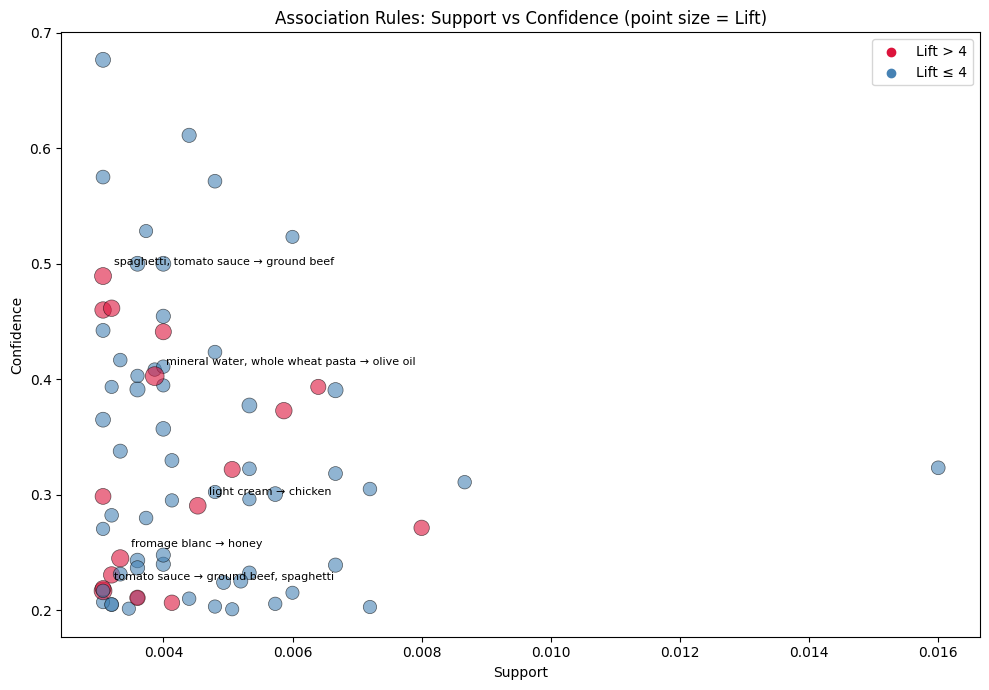

In [32]:
import matplotlib.pyplot as plt

high_lift = parsed_rules["Lift"] > 4
colors = high_lift.map({True: "crimson", False: "steelblue"})

plt.figure(figsize=(10, 7))
plt.scatter(
    parsed_rules["Support"],
    parsed_rules["Confidence"],
    s=parsed_rules["Lift"] * 30,
    c=colors,
    alpha=0.6,
    edgecolors="black",
    linewidths=0.5,
)
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Association Rules: Support vs Confidence (point size = Lift)")

# Annotate the top 5 rules by lift
top5 = parsed_rules.nlargest(5, "Lift")
for _, rule in top5.iterrows():
    label = f"{rule['LHS']} → {rule['RHS']}"
    plt.annotate(
        label,
        (rule["Support"], rule["Confidence"]),
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=8,
    )

plt.scatter([], [], c="crimson", label="Lift > 4")
plt.scatter([], [], c="steelblue", label="Lift ≤ 4")
plt.legend()
plt.tight_layout()
plt.show()

### b) Horizontal bar chart: top 15 rules by Lift, color-coded by Confidence

C:\Users\Uma\AppData\Local\Temp\ipykernel_56236\3322733491.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("coolwarm")


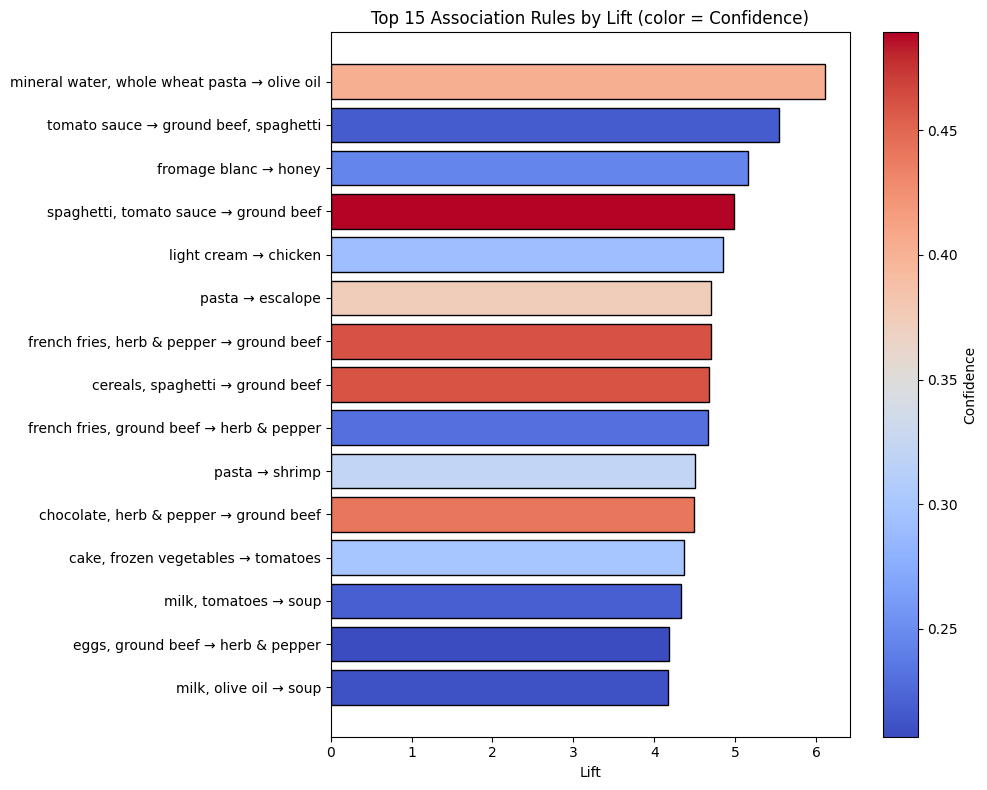

In [33]:
import matplotlib.pyplot as plt
import matplotlib as mpl

top15 = parsed_rules.nlargest(15, "Lift").iloc[::-1]
rule_names = [f"{row.LHS} → {row.RHS}" for row in top15.itertuples()]

cmap = mpl.cm.get_cmap("coolwarm")
norm = mpl.colors.Normalize(vmin=top15["Confidence"].min(), vmax=top15["Confidence"].max())
bar_colors = [cmap(norm(value)) for value in top15["Confidence"]]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(rule_names, top15["Lift"], color=bar_colors, edgecolor="black")
ax.set_xlabel("Lift")
ax.set_title("Top 15 Association Rules by Lift (color = Confidence)")

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Confidence")

plt.tight_layout()
plt.show()

### c) item_frequency_chart(transactions, top_n=20)

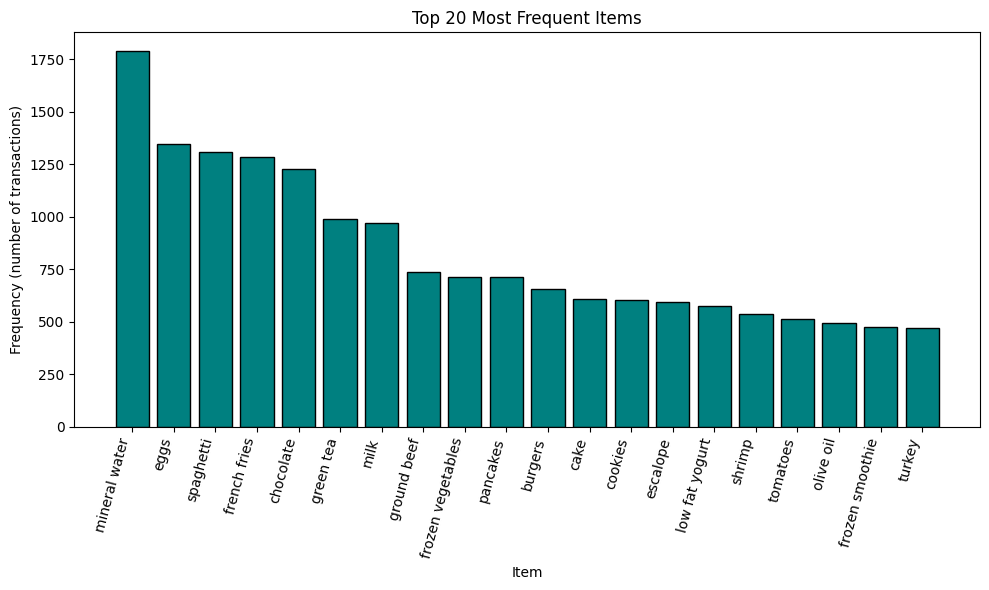

,item,frequency
0,mineral water,1788
1,eggs,1348
2,spaghetti,1306
3,french fries,1282
4,chocolate,1229
5,green tea,991
6,milk,972
7,ground beef,737
8,frozen vegetables,715
9,pancakes,713


In [34]:
import matplotlib.pyplot as plt
from collections import Counter


def item_frequency_chart(transactions, top_n=20):
    counts = Counter()
    for transaction in transactions:
        counts.update(transaction)

    top_items = counts.most_common(top_n)
    items = [item for item, _ in top_items]
    frequencies = [freq for _, freq in top_items]

    plt.figure(figsize=(10, 6))
    plt.bar(items, frequencies, color="teal", edgecolor="black")
    plt.xticks(rotation=75, ha="right")
    plt.xlabel("Item")
    plt.ylabel("Frequency (number of transactions)")
    plt.title(f"Top {top_n} Most Frequent Items")
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(top_items, columns=["item", "frequency"])


frequent_items = item_frequency_chart(transactions, top_n=20)
frequent_items

In [35]:
"""
Discussion: Comparing this frequency ranking to the high-lift rules shows that
high-frequency items (e.g., mineral water, eggs, spaghetti, french fries) 
rarely dominate the high-lift rule list example: "mineral water" appears
mostly as a common co-occurring item with modest lift, while the strongest
lift rules liek "mineral water, whole wheat pasta -> olive oil" at lift 6.12, 
"fromage blanc -> honey" at lift 5.16) pair comparatively rare items. 
This makes sense statistically since lift measures how much often two items
co-occur than chance would predict, and very frequent items co-occur with 
almost everything by just volume, which pulls their lift toward 1 (independence). 
Less common items that do co-occur tend to do so for a real behavioral reason (exmple:
a recipe pairing), producing a much larger lift. So high-frequency items
tend to anchor the rules, but not high-lift ones.
"""

'\nDiscussion: Comparing this frequency ranking to the high-lift rules shows that\nhigh-frequency items (e.g., mineral water, eggs, spaghetti, french fries) \nrarely dominate the high-lift rule list example: "mineral water" appears\nmostly as a common co-occurring item with modest lift, while the strongest\nlift rules liek "mineral water, whole wheat pasta -> olive oil" at lift 6.12, \n"fromage blanc -> honey" at lift 5.16) pair comparatively rare items. \nThis makes sense statistically since lift measures how much often two items\nco-occur than chance would predict, and very frequent items co-occur with \nalmost everything by just volume, which pulls their lift toward 1 (independence). \nLess common items that do co-occur tend to do so for a real behavioral reason (exmple:\na recipe pairing), producing a much larger lift. So high-frequency items\ntend to anchor the rules, but not high-lift ones.\n'